In [1]:
import os 
import glob
import pickle as pkl
import MDAnalysis as mda
import matplotlib.pyplot as plt
import pyemma as emma

import numpy as np
import scipy as sc

os.chdir('/media/volume/Orai1_rep0/Orai1_analysis')

### MANUSCRIPT PREPAREATION

#### 1. RMSF

In [2]:
"""
Complete Multi-Replica RMSF Analysis Pipeline
Computes RMSF for 3 replicas, pools statistics, generates publication-quality plots
Handles: Orai1 (6 subunits × 251 AA) + CAD (12 subunits × 103 AA)
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import MDAnalysis as mda
from scipy import stats
import pickle
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION — EDIT THESE
# ============================================================================

cwd = os.getcwd()
sys_name = 'WT_refined_loop'
replicas = [1, 2, 3]

# Directories
dirs = {}
dirs['sys'] = os.path.join(cwd, 'system', sys_name)
dirs['analysis'] = os.path.join(cwd, 'analysis', sys_name)
dirs['pp_sim'] = os.path.join(cwd, 'postprocessed_simulation', sys_name)
dirs['Manuscript'] = os.path.join(cwd, 'Manuscript')

for key in dirs:
    os.makedirs(dirs[key], exist_ok=True)

psf = os.path.join(dirs['sys'], 'protein.pdb')

# System geometry
N_ORAI1 = 6
AA_ORAI1 = 251
N_CAD = 12
AA_CAD = 103

print("="*80)
print("MULTI-REPLICA RMSF ANALYSIS PIPELINE")
print("="*80)
print(f"System: {sys_name}")
print(f"Replicas: {replicas}")
print(f"Topology: {psf}")
print(f"Analysis dir: {dirs['analysis']}")
print("="*80 + "\n")

# ============================================================================
# STEP 1: LOAD OR COMPUTE RMSF FOR ALL REPLICAS
# ============================================================================

print("STEP 1: Loading/computing RMSF for all replicas...")
print("-"*80)

def load_or_compute_rmsf(replica_id, psf, pp_sim_dir, analysis_dir, force_recompute=False):
    """Load RMSF from .npy file if exists, otherwise compute."""
    rep_dir = os.path.join(analysis_dir, 'structural', f'Rep-{replica_id}')
    os.makedirs(rep_dir, exist_ok=True)
    npy_path = os.path.join(rep_dir, f'RMSF_Rep-{replica_id}.npy')
    
    if os.path.exists(npy_path) and not force_recompute:
        print(f"Rep-{replica_id}: Loading from {npy_path}")
        rmsf = np.load(npy_path)
        print(f"  Loaded: {len(rmsf)} atoms, mean RMSF={np.mean(rmsf):.3f} Å")
        return rmsf
    else:
        print(f"Rep-{replica_id}: {npy_path} NOT FOUND!")
        
# Load RMSF for all replicas
rmsf_dict = {}
for rep in replicas:
    rmsf_dict[rep] = load_or_compute_rmsf(rep, psf, dirs['pp_sim'], dirs['analysis'])

print("\n✓ RMSF loaded/computed\n")


MULTI-REPLICA RMSF ANALYSIS PIPELINE
System: WT_refined_loop
Replicas: [1, 2, 3]
Topology: /media/volume/Orai1_rep0/Orai1_analysis/system/WT_refined_loop/protein.pdb
Analysis dir: /media/volume/Orai1_rep0/Orai1_analysis/analysis/WT_refined_loop

STEP 1: Loading/computing RMSF for all replicas...
--------------------------------------------------------------------------------
Rep-1: Loading from /media/volume/Orai1_rep0/Orai1_analysis/analysis/WT_refined_loop/structural/Rep-1/RMSF_Rep-1.npy
  Loaded: 2742 atoms, mean RMSF=2.216 Å
Rep-2: Loading from /media/volume/Orai1_rep0/Orai1_analysis/analysis/WT_refined_loop/structural/Rep-2/RMSF_Rep-2.npy
  Loaded: 2742 atoms, mean RMSF=2.281 Å
Rep-3: Loading from /media/volume/Orai1_rep0/Orai1_analysis/analysis/WT_refined_loop/structural/Rep-3/RMSF_Rep-3.npy
  Loaded: 2742 atoms, mean RMSF=2.665 Å

✓ RMSF loaded/computed



In [4]:
#!/usr/bin/env python
"""
Export per-residue RMSF (mean / sem / std per chain) to a plot-ready .xlsx
"""

import numpy as np
import pandas as pd
from openpyxl import load_workbook
from openpyxl.chart import LineChart, Reference

data = stats_pooled

OUT     = os.path.join(dirs['Manuscript'], 'data/RMSF_per_chain.xlsx')
OFFSET  = {'orai1': 50, 'cad': 341}   # model numbering -> real residue number
ORAI1   = list('ABCDEF')
CAD     = list('GHIJKLMNOPQR')

# ---- group chains by array length so residue axes line up ------------------
lengths = {c: len(v['mean']) for c, v in data.items()}
print('array lengths:', lengths)

groups = {}
for chain, n in lengths.items():
    groups.setdefault(n, []).append(chain)

def group_name(chains):
    if all(c in ORAI1 for c in chains):
        return 'Orai1', OFFSET['orai1']
    if all(c in CAD for c in chains):
        return 'CAD', OFFSET['cad']
    return f'chains_{chains[0]}-{chains[-1]}', 0

# ---- build one sheet per group, plus a long-format sheet -------------------
sheets, long_rows = {}, []

for n, chains in sorted(groups.items()):
    chains = sorted(chains)
    name, off = group_name(chains)
    resids = np.arange(n) + off + 1

    block = {'Residue': resids}
    for c in chains:
        block[f'{c}_mean'] = data[c]['mean']
    for c in chains:
        block[f'{c}_sem'] = data[c]['sem']
    for c in chains:
        block[f'{c}_std'] = data[c]['std']

    sheets[name] = pd.DataFrame(block)

    for c in chains:
        long_rows.append(pd.DataFrame({
            'Chain':    c,
            'Group':    name,
            'Residue':  resids,
            'RMSF':     data[c]['mean'],
            'SEM':      data[c]['sem'],
            'STD':      data[c]['std'],
        }))

sheets['long_format'] = pd.concat(long_rows, ignore_index=True)

with pd.ExcelWriter(OUT, engine='openpyxl') as xl:
    for name, df in sheets.items():
        df.to_excel(xl, sheet_name=name[:31], index=False, float_format='%.4f')

# ---- drop a ready-made line chart onto each per-group sheet ----------------
wb = load_workbook(OUT)
for name, df in sheets.items():
    if name == 'long_format':
        continue
    ws = wb[name[:31]]
    n_mean = sum(col.endswith('_mean') for col in df.columns)

    ch = LineChart()
    ch.title    = f'{name} RMSF per residue'
    ch.y_axis.title = 'RMSF (Å)'
    ch.x_axis.title = 'Residue'
    ch.height, ch.width = 10, 24

    ch.add_data(Reference(ws, min_col=2, max_col=1 + n_mean,
                          min_row=1, max_row=ws.max_row),
                titles_from_data=True)
    ch.set_categories(Reference(ws, min_col=1, min_row=2, max_row=ws.max_row))
    for s in ch.series:
        s.graphicalProperties.line.width = 12000
        s.smooth = False

    ws.add_chart(ch, f'A{ws.max_row + 3}')

wb.save(OUT)
print(f'wrote {OUT}: {list(sheets)}')

array lengths: {'A': 251, 'B': 251, 'C': 251, 'D': 251, 'E': 251, 'F': 251, 'G': 103, 'H': 103, 'I': 103, 'J': 103, 'K': 103, 'L': 103, 'M': 103, 'N': 103, 'O': 103, 'P': 103, 'Q': 103, 'R': 103}
wrote /media/volume/Orai1_rep0/Orai1_analysis/Manuscript/data/RMSF_per_chain.xlsx: ['CAD', 'Orai1', 'long_format']


STEP 3: Generating Orai1 RMSF plot...
--------------------------------------------------------------------------------


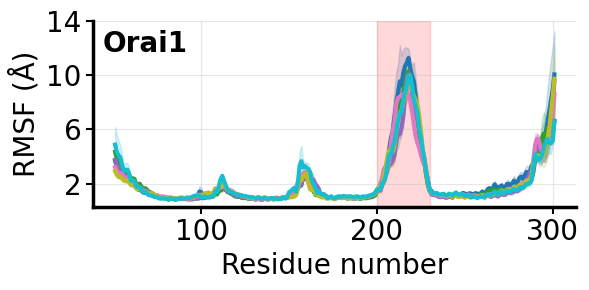

In [22]:
fts = 20
print("STEP 3: Generating Orai1 RMSF plot...")
print("-"*80)

fig, ax = plt.subplots(figsize=(6, 3))

orai1_segids = [segids[i] for i in range(N_ORAI1)]
colors_orai1 = plt.cm.tab10(np.linspace(0, 1, N_ORAI1))

# Orai1 offset in sequence (shift by +50)
orai1_offset = 50

for idx, segid in enumerate(orai1_segids):
    residue_nums = np.arange(1, AA_ORAI1 + 1) + orai1_offset  # Shift by +50
    mean_rmsf = stats_pooled[segid]['mean']
    sem_rmsf = stats_pooled[segid]['sem']
    
    ax.plot(residue_nums, mean_rmsf, label=segid, linewidth=3., 
           color=colors_orai1[idx], marker='o', markersize=2, markevery=30)
    ax.fill_between(residue_nums, mean_rmsf - sem_rmsf, mean_rmsf + sem_rmsf,
                     alpha=0.2, color=colors_orai1[idx])

# ax.axvspan(15, 30, alpha=0.15, color='orange', label='N-terminal binding site')
# ax.axvspan(210, 230, alpha=0.15, color='green', label='C-terminal CAD binding')
ax.axvspan(150 + orai1_offset, 180 + orai1_offset, alpha=0.15, color='red', label='Pore (TM3-TM4)')
# ax.axvspan(58, 66, alpha=0.15, color='purple', label='Pore (TM1)')

all_orai1_rmsf = np.concatenate([stats_pooled[s]['mean'] for s in orai1_segids])
ymin, ymax = np.min(all_orai1_rmsf), np.max(all_orai1_rmsf)
margin = 0.5
ax.set_ylim((ymin - margin, 14))

# Set specific y-axis ticks
ax.set_yticks([2, 6, 10, 14])

ax.set_xlabel('Residue number', fontsize=fts)
ax.set_ylabel('RMSF (Å)', fontsize=fts)
#ax.set_title(f'Orai1 Fluctuation ({len(replicas)} replicas, mean ± SEM)', fontsize=14, fontweight='bold')
#ax.legend(loc='upper left', ncol=2, fontsize=10)
ax.grid(True, alpha=0.3)

ax.text(0.02, 0.95, 'Orai1', transform=ax.transAxes,
        fontsize=fts, fontweight='bold',
        ha='left', va='top')

# Set tick fontsize to match label fontsize
ax.tick_params(axis='both', which='major', labelsize=fts, width=1.5, length=5)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2.5)

sns.despine()

plt.tight_layout()
#orai1_path = os.path.join(dirs['Manuscript'], 'Raw/Fig6C/RMSF_Orai1_multi_replica.png')
#plt.savefig(orai1_path, dpi=300, bbox_inches='tight')
#print(f"Saved: {orai1_path}")
plt.show()


STEP 4a: Generating CAD plot (Option 1: Multi-line)...
--------------------------------------------------------------------------------


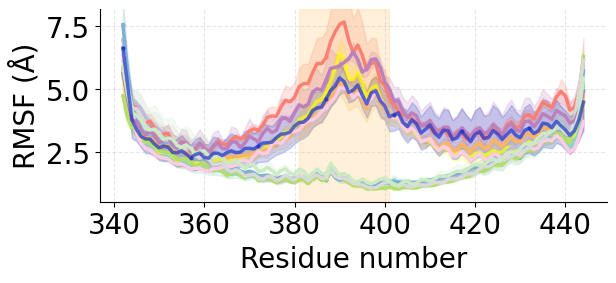

In [23]:
# ============================================================================
# STEP 4: PLOT CAD - OPTION 1: Classic multi-line
# ============================================================================

print("\nSTEP 4a: Generating CAD plot (Option 1: Multi-line)...")
print("-"*80)

fig, ax = plt.subplots(figsize=(6., 3.))

cad_segids = [segids[N_ORAI1 + i] for i in range(N_CAD)]

# Create custom colors: H and R with distinct colors
colors_cad = plt.cm.Set3(np.linspace(0, 1, N_CAD))

# Find indices of H and R
h_idx = cad_segids.index('H')
r_idx = cad_segids.index('R')

# Assign distinct colors to H and R (RGBA: Red, Green, Blue, Alpha)
colors_cad[h_idx] = [1.0, 1.0, 0.0, 0.7]  # Yellow for H
colors_cad[r_idx] = [0.1, 0.2, 0.8, 0.7]  # Dark blue for R

# CAD offset in sequence (starts at residue 341)
cad_offset = 341

for idx, segid in enumerate(cad_segids):
    residue_nums = np.arange(1, AA_CAD + 1) + cad_offset  # Shift by +341
    mean_rmsf = stats_pooled[segid]['mean']
    sem_rmsf = stats_pooled[segid]['sem']
    
    ax.plot(residue_nums, mean_rmsf, label=segid, linewidth=2.5, 
           color=colors_cad[idx], marker='o', markersize=2, markevery=15)
    ax.fill_between(residue_nums, mean_rmsf - sem_rmsf, mean_rmsf + sem_rmsf,
                     alpha=0.2, color=colors_cad[idx])

# Plot TM2-TM3 annotation with shifted indices
ax.axvspan(40 + cad_offset, 60 + cad_offset, alpha=0.15, color='orange', label='Apex')

all_cad_rmsf = np.concatenate([stats_pooled[s]['mean'] for s in cad_segids])
ymin, ymax = np.min(all_cad_rmsf), np.max(all_cad_rmsf)
margin = 0.5
ax.set_ylim((ymin - margin, ymax + margin))

ax.set_xlabel('Residue number', fontsize=fts)
ax.set_ylabel('RMSF (Å)', fontsize=fts)

# Get handles and labels from the plot
handles, labels = ax.get_legend_handles_labels()

# Define pair order: H-G, J-I, L-K, N-M, P-O, R-Q, TM2-TM3
pair_order = ['H', 'G', 'J', 'I', 'L', 'K', 'N', 'M', 'P', 'O', 'R', 'Q', 'Apex']

# Reorganize handles and labels according to pair order
reordered_handles = []
reordered_labels = []

for label in pair_order:
    try:
        idx = labels.index(label)
        reordered_handles.append(handles[idx])
        reordered_labels.append(labels[idx])
    except ValueError:
        pass

# Create legend with all items in one row (below the plot)
#ax.legend(reordered_handles, reordered_labels, loc='upper center', 
#         bbox_to_anchor=(0.5, -0.35), fontsize=9, ncol=7, frameon=True)

ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=fts)

sns.despine()

plt.tight_layout()
#cad_multiline_path = os.path.join(dirs['Manuscript'], 'Raw/Fig6C/RMSF_CAD_multiline.png')
#plt.savefig(cad_multiline_path, dpi=300, bbox_inches='tight')
#print(f"Saved: {cad_multiline_path}")
plt.show()


Generating combined Orai1 + CAD RMSF figure...
--------------------------------------------------------------------------------
Saved: /media/volume/Orai1_rep0/Orai1_analysis/Manuscript/Raw/Fig6C/RMSF_Orai1_CAD_combined.png


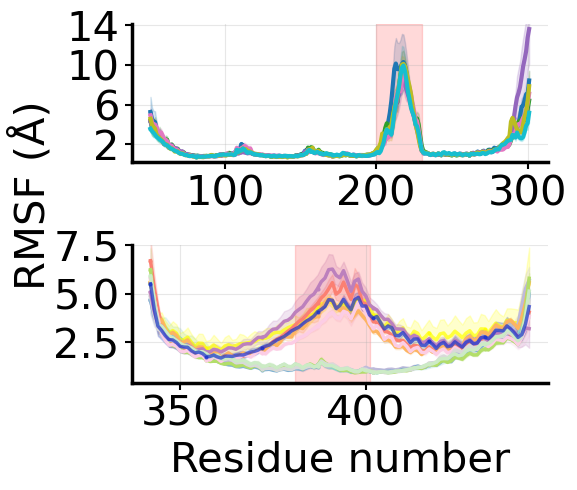

In [72]:
# ============================================================================
# COMBINED FIGURE: Orai1 (top) + CAD (bottom), shared x and y labels
# ============================================================================
print("\nGenerating combined Orai1 + CAD RMSF figure...")
print("-"*80)

fts = 30

fig, axes = plt.subplots(2, 1, figsize=(6, 5))
ax_orai1, ax_cad = axes

# ---------------------------------------------------------------- Orai1 panel
orai1_segids = [segids[i] for i in range(N_ORAI1)]
colors_orai1 = plt.cm.tab10(np.linspace(0, 1, N_ORAI1))
orai1_offset = 50                      # construct index -> full-length Orai1

for idx, segid in enumerate(orai1_segids):
    residue_nums = np.arange(1, AA_ORAI1 + 1) + orai1_offset
    mean_rmsf = stats_pooled[segid]['mean']
    sem_rmsf = stats_pooled[segid]['sem']

    ax_orai1.plot(residue_nums, mean_rmsf, label=segid, linewidth=3.,
                  color=colors_orai1[idx], marker='o', markersize=2, markevery=30)
    ax_orai1.fill_between(residue_nums, mean_rmsf - sem_rmsf, mean_rmsf + sem_rmsf,
                          alpha=0.2, color=colors_orai1[idx])

ax_orai1.axvspan(150 + orai1_offset, 180 + orai1_offset,
                 alpha=0.15, color='red', label='Pore (TM3-TM4)')

all_orai1_rmsf = np.concatenate([stats_pooled[s]['mean'] for s in orai1_segids])
ymin, ymax = np.min(all_orai1_rmsf), np.max(all_orai1_rmsf)
margin = 0.5
ax_orai1.set_ylim((ymin - margin, ymax + margin))
ax_orai1.set_yticks([2.0, 6.0, 10, 14])

#ax_orai1.text(0.06, 0.95, 'Orai1', transform=ax_orai1.transAxes,
#              fontsize=fts, fontweight='bold', ha='left', va='top')

ax_orai1.grid(True, alpha=0.3)
ax_orai1.tick_params(axis='both', which='major', labelsize=fts, width=1.5, length=5)
ax_orai1.spines[['top', 'right']].set_visible(False)
ax_orai1.spines[['left', 'bottom']].set_linewidth(2.5)

# ------------------------------------------------------------------ CAD panel
cad_segids = [segids[N_ORAI1 + i] for i in range(N_CAD)]
colors_cad = plt.cm.Set3(np.linspace(0, 1, N_CAD))

# distinct colours for H and R so they stand out from the Set3 pastels
h_idx = cad_segids.index('H')
r_idx = cad_segids.index('R')
colors_cad[h_idx] = [1.0, 1.0, 0.0, 0.7]      # yellow
colors_cad[r_idx] = [0.1, 0.2, 0.8, 0.7]      # dark blue

cad_offset = 341                       # construct index -> full-length STIM1

for idx, segid in enumerate(cad_segids):
    residue_nums = np.arange(1, AA_CAD + 1) + cad_offset
    mean_rmsf = stats_pooled[segid]['mean']
    sem_rmsf = stats_pooled[segid]['sem']

    ax_cad.plot(residue_nums, mean_rmsf, label=segid, linewidth=2.5,
                color=colors_cad[idx], marker='o', markersize=2, markevery=15)
    ax_cad.fill_between(residue_nums, mean_rmsf - sem_rmsf, mean_rmsf + sem_rmsf,
                        alpha=0.2, color=colors_cad[idx])

ax_cad.axvspan(40 + cad_offset, 60 + cad_offset,
               alpha=0.15, color='red', label='Apex')

all_cad_rmsf = np.concatenate([stats_pooled[s]['mean'] for s in cad_segids])
ymin, ymax = np.min(all_cad_rmsf), np.max(all_cad_rmsf)
ax_cad.set_ylim((ymin - margin, 7.5))
ax_cad.set_yticks([2.5, 5.0, 7.5])

#ax_cad.text(0.06, 0.95, 'CAD', transform=ax_cad.transAxes,
#            fontsize=fts, fontweight='bold', ha='left', va='top')

ax_cad.grid(True, alpha=0.3)
ax_cad.tick_params(axis='both', which='major', labelsize=fts, width=1.5, length=5)
ax_cad.spines[['top', 'right']].set_visible(False)
ax_cad.spines[['left', 'bottom']].set_linewidth(2.5)

# -------------------------------------------------------------- shared labels
ax_cad.set_xlabel('Residue number', fontsize=fts)     # bottom panel only
fig.supylabel('RMSF (Å)', fontsize=fts, x=0.05, y = 0.6)       # centred across both rows

plt.tight_layout()

combined_path = os.path.join(dirs['Manuscript'], 'Raw/Fig6C/RMSF_Orai1_CAD_combined.png')
plt.savefig(combined_path, dpi=300, bbox_inches='tight')
print(f"Saved: {combined_path}")
plt.show()


Generating combined Orai1 + CAD RMSF figure...
--------------------------------------------------------------------------------
Saved: /media/volume/Orai1_rep0/Orai1_analysis/Manuscript/Raw/Fig6C/RMSF_Orai1_CAD_combined.png


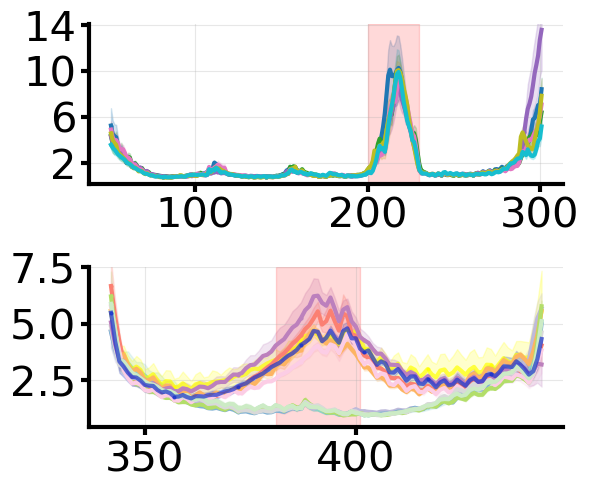

In [179]:
# ============================================================================
# COMBINED FIGURE: Orai1 (top) + CAD (bottom), shared x and y labels
# ============================================================================
print("\nGenerating combined Orai1 + CAD RMSF figure...")
print("-"*80)

fts = 30
fig, axes = plt.subplots(2, 1, figsize=(6, 5))
ax_orai1, ax_cad = axes

# ---------------------------------------------------------------- Orai1 panel
orai1_segids = [segids[i] for i in range(N_ORAI1)]
colors_orai1 = plt.cm.tab10(np.linspace(0, 1, N_ORAI1))
orai1_offset = 50                      # construct index -> full-length Orai1

for idx, segid in enumerate(orai1_segids):
    residue_nums = np.arange(1, AA_ORAI1 + 1) + orai1_offset
    mean_rmsf = stats_pooled[segid]['mean']
    sem_rmsf = stats_pooled[segid]['sem']
    ax_orai1.plot(residue_nums, mean_rmsf, label=segid, linewidth=3.,
                  color=colors_orai1[idx], marker='o', markersize=2, markevery=30)
    ax_orai1.fill_between(residue_nums, mean_rmsf - sem_rmsf, mean_rmsf + sem_rmsf,
                          alpha=0.2, color=colors_orai1[idx])

ax_orai1.axvspan(150 + orai1_offset, 180 + orai1_offset,
                 alpha=0.15, color='red', label='Pore (TM3-TM4)')

all_orai1_rmsf = np.concatenate([stats_pooled[s]['mean'] for s in orai1_segids])
ymin, ymax = np.min(all_orai1_rmsf), np.max(all_orai1_rmsf)
margin = 0.5
ax_orai1.set_ylim((ymin - margin, ymax + margin))
ax_orai1.set_yticks([2.0, 6.0, 10, 14])
#ax_orai1.text(0.06, 0.95, 'Orai1', transform=ax_orai1.transAxes,
#              fontsize=fts, fontweight='bold', ha='left', va='top')

# ------------------------------------------------------------------ CAD panel
cad_segids = [segids[N_ORAI1 + i] for i in range(N_CAD)]
colors_cad = plt.cm.Set3(np.linspace(0, 1, N_CAD))

# distinct colours for H and R so they stand out from the Set3 pastels
h_idx = cad_segids.index('H')
r_idx = cad_segids.index('R')
colors_cad[h_idx] = [1.0, 1.0, 0.0, 0.7]      # yellow
colors_cad[r_idx] = [0.1, 0.2, 0.8, 0.7]      # dark blue

cad_offset = 341                       # construct index -> full-length STIM1

for idx, segid in enumerate(cad_segids):
    residue_nums = np.arange(1, AA_CAD + 1) + cad_offset
    mean_rmsf = stats_pooled[segid]['mean']
    sem_rmsf = stats_pooled[segid]['sem']
    ax_cad.plot(residue_nums, mean_rmsf, label=segid, linewidth=3,
                color=colors_cad[idx], marker='o', markersize=2, markevery=15)
    ax_cad.fill_between(residue_nums, mean_rmsf - sem_rmsf, mean_rmsf + sem_rmsf,
                        alpha=0.2, color=colors_cad[idx])

ax_cad.axvspan(40 + cad_offset, 60 + cad_offset,
               alpha=0.15, color='red', label='Apex')

all_cad_rmsf = np.concatenate([stats_pooled[s]['mean'] for s in cad_segids])
ymin, ymax = np.min(all_cad_rmsf), np.max(all_cad_rmsf)
ax_cad.set_ylim((ymin - margin, 7.5))
ax_cad.set_yticks([2.5, 5.0, 7.5])
#ax_cad.text(0.06, 0.95, 'CAD', transform=ax_cad.transAxes,
#            fontsize=fts, fontweight='bold', ha='left', va='top')

# ------------------------------------------------------- shared panel styling
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=fts, width=3, length=6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(3)

# -------------------------------------------------------------- shared labels
#ax_cad.set_xlabel('Residue number', fontsize=fts)     # bottom panel only
#fig.supylabel('RMSF (Å)', fontsize=fts, x=0.05, y=0.6)  # centred across both rows

plt.tight_layout()

combined_path = os.path.join(dirs['Manuscript'], 'Raw/Fig6C/RMSF_Orai1_CAD_combined.png')
plt.savefig(combined_path, dpi=600, bbox_inches='tight')
print(f"Saved: {combined_path}")
plt.show()

In [64]:
"""
Project pooled RMSF onto the B-factor column of a PDB.

Two things this handles:
  1. Output keyed by (chain, resnum, icode) so chains cannot overwrite
     each other. Keying on resnum alone silently collapses all 18 chains
     onto whichever one is parsed last.
  2. CHAIN_MAP translates a structure chain letter to the segid whose
     RMSF array should be read, for structures whose labels differ from
     the MD topology.
"""

import pickle
import numpy as np
from collections import defaultdict

pdb_file = '/media/volume/Orai1_rep0/Orai1_analysis/Manuscript/data/boltz2_plddt.pdb'
pkl_file = '/media/volume/Orai1_rep0/Orai1_analysis/Manuscript/data/RMSF_pooled_stats_3replicas.pkl'
out_pdb  = pdb_file.replace('.pdb', '_RMSF.pdb')

# Structure chain letter -> segid in the RMSF data.
# Q and R are swapped in this structure relative to the MD topology.
# Anything not listed maps to itself.
CHAIN_MAP = {'Q': 'R', 'R': 'Q'}

UNMAPPED = -1.0   # B-factor flag for atoms with no RMSF value

# ---------------------------------------------------------------- load
with open(pkl_file, 'rb') as f:
    stats = pickle.load(f)

with open(pdb_file) as f:
    lines = f.readlines()

# ------------------------------------- first pass: CA atoms -> RMSF index
pos        = defaultdict(int)    # per-chain running CA counter
first_res  = {}                  # chain -> first residue number seen
rmsf_by_key = {}                 # (chain, resnum, icode) -> RMSF
missing    = defaultdict(int)    # chains with no segid in the .pkl
overrun    = defaultdict(int)    # CA atoms past the end of the array
gaps       = []                  # numbering discontinuities

for line in lines:
    if not line.startswith('ATOM') or line[12:16].strip() != 'CA':
        continue

    chain  = line[21]
    icode  = line[26]
    try:
        resnum = int(line[22:26])
    except ValueError:
        continue

    segid = CHAIN_MAP.get(chain, chain)
    if segid not in stats:
        missing[chain] += 1
        continue

    first_res.setdefault(chain, resnum)

    i_count = pos[chain]           # index by CA order
    i_num   = resnum - first_res[chain]   # index by residue numbering
    pos[chain] += 1

    if i_count != i_num:
        gaps.append((chain, resnum, i_count, i_num))

    arr = stats[segid]['mean']
    if i_count < len(arr):
        rmsf_by_key[(chain, resnum, icode)] = float(arr[i_count])
    else:
        overrun[chain] += 1

# ------------------------------------------- second pass: write B-factors
written = defaultdict(list)

with open(out_pdb, 'w') as out:
    for line in lines:
        if not line.startswith(('ATOM', 'HETATM')):
            out.write(line)
            continue
        try:
            key = (line[21], int(line[22:26]), line[26])
        except ValueError:
            out.write(line)
            continue

        if key in rmsf_by_key:
            v = rmsf_by_key[key]
            written[line[21]].append(v)
            out.write(line[:60] + f"{v:6.2f}" + line[66:])
        else:
            out.write(line[:60] + f"{UNMAPPED:6.2f}" + line[66:])

# ------------------------------------------------------------ verification
print("=" * 62)
print("chain -> segid   nres   written_mean   pkl_mean   match")
print("-" * 62)

bad = []
for chain in sorted(pos):
    segid = CHAIN_MAP.get(chain, chain)
    w = np.mean(written[chain]) if written[chain] else float('nan')
    p = np.mean(stats[segid]['mean'])
    ok = abs(w - p) < 0.05
    if not ok:
        bad.append(chain)
    print(f"  {chain}   ->   {segid}   {pos[chain]:5d}   {w:10.3f}   {p:9.3f}   "
          f"{'yes' if ok else 'NO'}")

print("-" * 62)

for chain, n in sorted(missing.items()):
    print(f"chain {chain}: {n} CA atoms, no segid '{CHAIN_MAP.get(chain, chain)}' in .pkl")
for chain, n in sorted(overrun.items()):
    print(f"chain {chain}: {n} CA atoms past end of RMSF array (structure longer than MD)")
if gaps:
    print(f"{len(gaps)} numbering discontinuities; first few:")
    for chain, resnum, ic, inum in gaps[:5]:
        print(f"  chain {chain} res {resnum}: CA-order idx {ic}, resnum idx {inum}")
    print("  -> a gap shifts CA-order indexing; check these chains")

n_expected = sum(len(stats[s]['mean']) for s in stats)
print(f"\nresidues mapped: {len(rmsf_by_key)} / {n_expected} in .pkl")
print(f"wrote: {out_pdb}")
if bad:
    print(f"\nchains not matching: {bad} -- fix CHAIN_MAP before using this file")
else:
    print("\nall chains match their .pkl means")
print(f"atoms with no RMSF carry B = {UNMAPPED:.2f}")
print("=" * 62)

chain -> segid   nres   written_mean   pkl_mean   match
--------------------------------------------------------------
  A   ->   A     251        1.877       1.959   NO
  B   ->   B     251        1.750       1.832   NO
  C   ->   C     251        1.871       1.942   NO
  D   ->   D     251        1.727       1.802   NO
  E   ->   E     251        1.752       1.827   NO
  F   ->   F     251        1.610       1.686   NO
  G   ->   G     103        1.871       1.847   yes
  H   ->   H     103        3.270       3.286   yes
  I   ->   I     103        1.864       1.844   yes
  J   ->   J     103        2.950       2.964   yes
  K   ->   K     103        1.764       1.745   yes
  L   ->   L     103        2.889       2.890   yes
  M   ->   M     103        1.722       1.702   yes
  N   ->   N     103        2.583       2.595   yes
  O   ->   O     103        1.812       1.787   yes
  P   ->   P     103        3.294       3.316   yes
  Q   ->   R     103        2.918       2.935   yes
  R

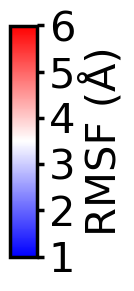

In [73]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fts = 30
vmin, vmax = 1.0, 6.0

fig, ax = plt.subplots(figsize=(0.35, 3.0))

cb = mpl.colorbar.ColorbarBase(
    ax,
    cmap=plt.cm.bwr,
    norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax),
    orientation='vertical',
)

cb.set_label('RMSF (Å)', fontsize=fts)
cb.set_ticks([1, 2, 3, 4, 5, 6])
cb.ax.tick_params(labelsize=fts, width = 2.5, length = 5.)
cb.outline.set_linewidth(2.5)

plt.savefig(f"{dirs['Manuscript']}/Raw/Fig6C/rmsf_colorbar_bwr.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

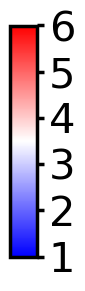

In [172]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fts = 30
vmin, vmax = 1.0, 6.0

fig, ax = plt.subplots(figsize=(0.35, 3.0))

cb = mpl.colorbar.ColorbarBase(
    ax,
    cmap=plt.cm.bwr,
    norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax),
    orientation='vertical',
)

#cb.set_label('RMSF (Å)', fontsize=fts)
cb.set_ticks([1, 2, 3, 4, 5, 6])
cb.ax.tick_params(labelsize=fts, width = 2.5, length = 5.)
cb.outline.set_linewidth(2.5)

plt.savefig(f"{dirs['Manuscript']}/Raw/Fig6C/rmsf_colorbar_bwr.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

#### 2. RMMSD

In [3]:
cwd = os.getcwd()
sys_name = 'WT_refined_loop'
dirs = {}
dirs['analysis'] = os.path.join(cwd, 'analysis')
dirs['wt'] =  os.path.join(dirs['analysis'], sys_name)
dirs['L223D'] =  os.path.join(dirs['analysis'], 'L223D')
dirs['Y208A'] =  os.path.join(dirs['analysis'], 'Y208A')
dirs['Manuscript'] = os.path.join(cwd, 'Manuscript')

rep1 = np.load(os.path.join(dirs['wt'], 'structural/Rep-1/RMSD_Rep-1.npy'))
rep2 = np.load(os.path.join(dirs['wt'], 'structural/Rep-2/RMSD_Rep-2.npy'))
rep3 = np.load(os.path.join(dirs['wt'], 'structural/Rep-3/RMSD_Rep-3.npy'))

L223D = np.load(os.path.join(dirs['L223D'], 'structural/RMSD/L223D.rep2_Rep-2.npy'))
Y208A = np.load(os.path.join(dirs['Y208A'], 'structural/RMSD/Y208A.rep1_Rep-1.npy'))


Generating RMSD plot...
--------------------------------------------------------------------------------


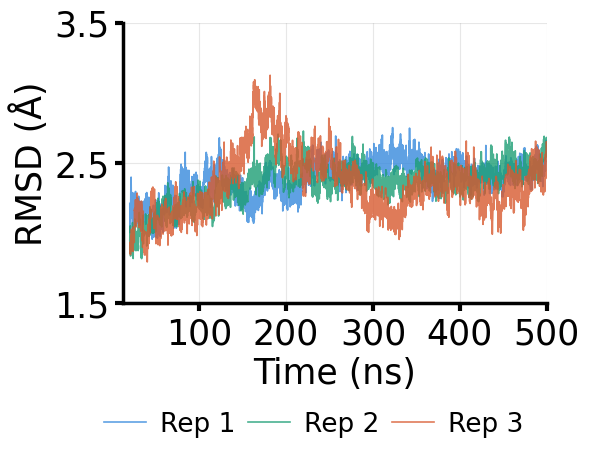

In [6]:
# ============================================================================
# RMSD across replicas -- styled to match the RMSF panels
# ============================================================================
print("\nGenerating RMSD plot...")
print("-" * 80)

T_TOTAL = 500.0   # ns per replica
T_START = 20.0    # discard first 20 ns (treated as extended equilibration)
X_PAD   = 8.0     # ns of blank space between the y-axis and the first data point
Y_MIN   = 1.5     # bottom of the y-axis
Y_CAP   = 3.5     # top of the y-axis

fts = 25
REP_COLORS = ['#378ADD', '#1D9E75', '#D85A30']

fig, ax = plt.subplots(figsize=(6, 5))

for i, (arr, c) in enumerate(zip([rep1, rep2, rep3], REP_COLORS)):
    dt = T_TOTAL / len(arr)                 # ns per frame
    time = np.arange(len(arr)) * dt
    m = time >= T_START                     # mask, robust to unequal frame counts
    ax.plot(time[m], arr[m], color=c, linewidth=1.2, alpha=0.8, label=f'Rep {i+1}')

ax.set_xlabel('Time (ns)', fontsize=fts)
ax.set_ylabel('RMSD (Å)', fontsize=fts)

ax.set_xlim(T_START - X_PAD, T_TOTAL)
ax.set_ylim(Y_MIN, Y_CAP)
ax.set_xticks([100, 200, 300, 400, 500])
ax.set_yticks([1.5, 2.5, 3.5])

# stop the left spine at the top tick instead of running past it
ax.spines['left'].set_bounds(Y_MIN, Y_CAP)

ax.legend(loc='upper center', bbox_to_anchor=(0.45, -0.3),
          ncol=3, fontsize=fts - 6, frameon=False,
          columnspacing=0.5, handlelength=1.6, handletextpad=0.5)

ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=fts, width=3, length=6)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2.5)

plt.tight_layout()
out = os.path.join(dirs['Manuscript'], 'Raw/Fig6A/RMSD_3replicas.png')
# plt.savefig(out, dpi=600, bbox_inches='tight')
# print(f"Saved: {out}")
plt.show()